#### Stochastic Simulation Project 1
Sophia Reiffenstein Petersen (s224222)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import scipy.stats as stats
import random
import pandas as pd
from functions_project1 import *

#### Part 1

Average time until death: 265.04 months
maximum time until death: 1151 months
minimum time until death: 1 months
95% confidence interval for the average time until death: (253.60, 276.47) months


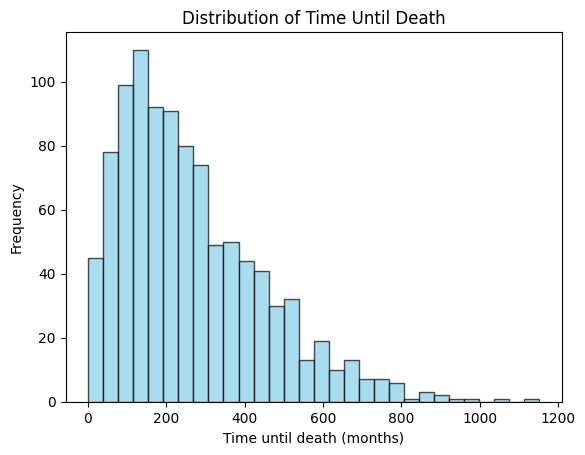

In [2]:
## Task 1
np.random.seed(42) 
n_women = 1000
death_times = cancer_simulation_women(n_women)

print(f"Average time until death: {np.mean([time for time, _ in death_times]):.2f} months")
print(f"maximum time until death: {np.max([time for time, _ in death_times])} months")
print(f"minimum time until death: {np.min([time for time, _ in death_times])} months")

lower_bound, upper_bound = conf_interval([time for time, _ in death_times])
print(f"95% confidence interval for the average time until death: ({lower_bound:.2f}, {upper_bound:.2f}) months")

plt.hist([time for time, _ in death_times], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
plt.title('Distribution of Time Until Death')
plt.xlabel('Time until death (months)')
plt.ylabel('Frequency')
plt.savefig('death_times_histogram.png')
plt.show()

In [3]:
proportion = proportion_local_recurrence(n_women)
print(f"Proportion of patients with local recurrence: {proportion:.4f}")

Proportion of patients with local recurrence: 0.5890


In [4]:
### Task 2

np.random.seed(42)
t = 120
p0 = np.array([1,0,0,0,0])
pt = p0 @ np.linalg.matrix_power(Probability_matrix, t)

print(f"Probability of being in each state after {t} months: {pt}")

# In your simulations, what is the distribution over the states at t = 120?

state_distribution = state_distribution_at_time_t(n_women, t)
print(f"Simulated distribution over states at t={t} months: {state_distribution}")

chi2_statistic, p_value = chi_square_test(state_distribution, pt)
print(f"Chi-square statistic: {chi2_statistic:.4f}, p-value: {p_value:.4f}")

Probability of being in each state after 120 months: [0.35902627 0.15895604 0.1660869  0.06774149 0.2481893 ]
Simulated distribution over states at t=120 months: [0.357 0.164 0.184 0.061 0.234]
Chi-square statistic: 0.0036, p-value: 1.0000


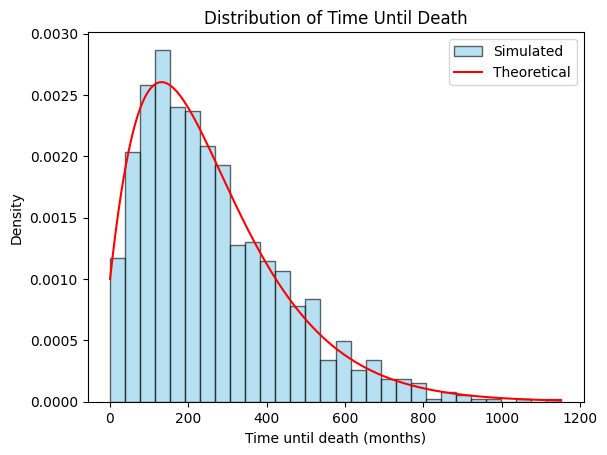

KS statistic: 0.0400, p-value: 0.4006


In [5]:
# Task 3
# lifetime distribution:
# P(T=t) = pi * (P_s)^t * ps
Ps = Probability_matrix[:4,:4]
ps = Probability_matrix[:4,4]
pi = p0[:4]

PT = np.zeros(max([time for time, _ in death_times]))
for t in range(1, len(PT)+1):
    PT[t-1] = pi @ np.linalg.matrix_power(Ps, t-1) @ ps

plt.hist([time for time, _ in death_times], bins=30, edgecolor='black', density=True, alpha=0.6, label='Simulated', color='skyblue')
plt.plot(range(1, len(PT)+1), PT/np.sum(PT), label='Theoretical', color='red')
plt.title('Distribution of Time Until Death')
plt.xlabel('Time until death (months)')
plt.ylabel('Density')
plt.legend()
plt.savefig('death_times_comparison.png')
plt.show()

ks_statistic, ks_p_value = stats.ks_2samp([time for time, _ in death_times], np.random.choice(range(1, max([time for time, _ in death_times])+1), size=1000, p=PT/np.sum(PT)))
print(f"KS statistic: {ks_statistic:.4f}, p-value: {ks_p_value:.4f}")

In [6]:
# Task 4
np.random.seed(42)
accepted_death_times = cancer_simulation_recurrence(1000)
mean_accepted_time = np.mean(accepted_death_times)

print(f"Estimated expected lifetime for women with recurrence within 12 months: {mean_accepted_time:.2f} months")

Estimated expected lifetime for women with recurrence within 12 months: 177.90 months


In [7]:
## Task 5
# Fraction that dies within first 350 months, simulating 200 women and doing it 100 times
np.random.seed(42)
avg_lifetimes = []
fractions = []

fractions = []
avg_lifetimes = []

for _ in range(100):
    death_times = cancer_simulation_women(200)
    times = [time for time, _ in death_times]

    fraction_dying_within_350 = np.mean([time <= 350 for time in times])
    
    fractions.append(fraction_dying_within_350)
    avg_lifetimes.append(np.mean(times))


print(f"Fraction of women dying within 350 months (mean over 100 simulations): {np.mean(fractions):.4f}")
conf_int_fraction = conf_interval(fractions)
print(f"95% confidence interval for the fraction dying within 350 months: [{conf_int_fraction[0]:.4f}, {conf_int_fraction[1]:.4f}]")

Fraction of women dying within 350 months (mean over 100 simulations): 0.7375
95% confidence interval for the fraction dying within 350 months: [0.7305, 0.7446]


In [8]:
X = np.array(avg_lifetimes)
Y = np.array(fractions)
c = np.cov(Y, X, ddof=1)[0, 1] / np.var(X, ddof=1)

control_variate_estimate = control_variate(Y, X, c)
print(f"Adjusted fraction of women dying within 350 months (control variate): {np.mean(control_variate_estimate):.4f}")
conf_int_cv = conf_interval(control_variate_estimate)

print(f"95% confidence interval for the adjusted fraction: [{conf_int_cv[0]:.4f}, {conf_int_cv[1]:.4f}]")

variance_reduction = 100 * (np.var(Y, ddof=1) - np.var(control_variate_estimate, ddof=1)) / np.var(Y, ddof=1)
print(f"Variance reduction achieved by control variate: {variance_reduction:.3f}%")

Adjusted fraction of women dying within 350 months (control variate): 0.7376
95% confidence interval for the adjusted fraction: [0.7341, 0.7410]
Variance reduction achieved by control variate: 76.246%


#### Part 2

Average lifetime from continuous-time simulation: 256.37 months
Standard deviation of lifetime from continuous-time simulation: 194.38 months
95% confidence interval for the average lifetime: (244.32, 268.42) months
95% confidence interval for the standard deviation of lifetime: (186.22, 203.29) months


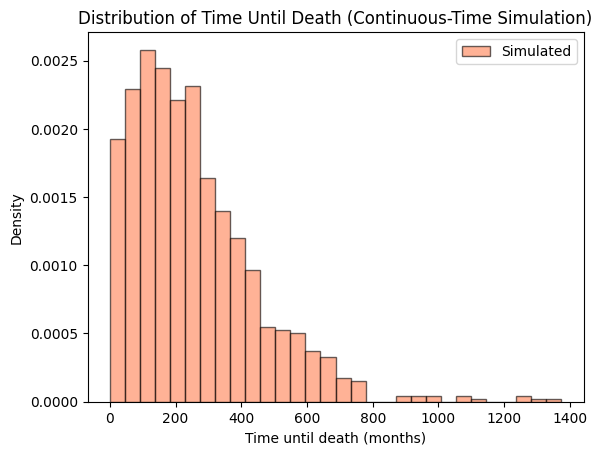

In [26]:
# Task 7
np.random.seed(42)
n = 1000
cont_sim_women = continuous_cancer_simulation(n, Q)
avg_lifetime_cont_sim = np.mean([time for time, _, _ in cont_sim_women])
std_lifetime_cont_sim = np.std([time for time, _, _ in cont_sim_women], ddof=1)
mean_conf_int_cont_sim = conf_interval([time for time, _, _ in cont_sim_women])
std_conf_int_cont_sim = conf_interval_std([time for time, _, _ in cont_sim_women])

print(f"Average lifetime from continuous-time simulation: {avg_lifetime_cont_sim:.2f} months")
print(f"Standard deviation of lifetime from continuous-time simulation: {std_lifetime_cont_sim:.2f} months")
print(f"95% confidence interval for the average lifetime: ({mean_conf_int_cont_sim[0]:.2f}, {mean_conf_int_cont_sim[1]:.2f}) months")
print(f"95% confidence interval for the standard deviation of lifetime: ({std_conf_int_cont_sim[0]:.2f}, {std_conf_int_cont_sim[1]:.2f}) months")

plt.hist([time for time, _, _ in cont_sim_women], bins=30, edgecolor='black', density=True, alpha=0.6, label='Simulated', color='coral')
x_values = np.linspace(0, max([time for time, _, _ in cont_sim_women]), 1000)
plt.title('Distribution of Time Until Death (Continuous-Time Simulation)')
plt.xlabel('Time until death (months)')
plt.ylabel('Density')
plt.legend()
plt.savefig('continuous_death_times_histogram.png')
plt.show()

In [17]:
np.random.seed(42)
prop_recurrence_cont_sim = continuous_recurrence(n, time_threshold=30.5, state_threshold=3)

print(f"Proportion of patients with recurrence within 30.5 months in continuous simulation: {prop_recurrence_cont_sim:.4f}")


Proportion of patients with recurrence within 30.5 months in continuous simulation: 0.0070


In [19]:
## Task 8
# F_T = 1 - p0 exp(Q_s t) 1
t = 120
Qs = Q[:4,:4]
p0 = np.array([1,0,0,0])

cont_distribution = continuous_cancer_simulation(n, Q)

empirical_Ft = np.mean([1 if time <= t else 0 for time, _, _ in cont_distribution])
theoretical_Ft = 1 - p0 @ scipy.linalg.expm(Qs * t) @ np.ones(4)

print(f"Empirical F(T) at t={t} months: {empirical_Ft:.4f}")
print(f"Theoretical F(T) at t={t} months: {theoretical_Ft:.4f}")

Empirical F(T) at t=120 months: 0.2440
Theoretical F(T) at t=120 months: 0.2483


In [21]:
continuous_matrix = np.array([time for time, _, _ in cont_distribution])

def theoretical_cdf(x):
    x = np.atleast_1d(x)
    return np.array([
        1 - p0 @ scipy.linalg.expm(Qs * t) @ np.ones(4)
        for t in x
    ])

ks_statistic, p_value =  stats.kstest(
    continuous_matrix,
    theoretical_cdf
)

print(f"KS statistic: {ks_statistic:.4f}")
print(f"p-value: {p_value:.4f}")

KS statistic: 0.0214
p-value: 0.7417


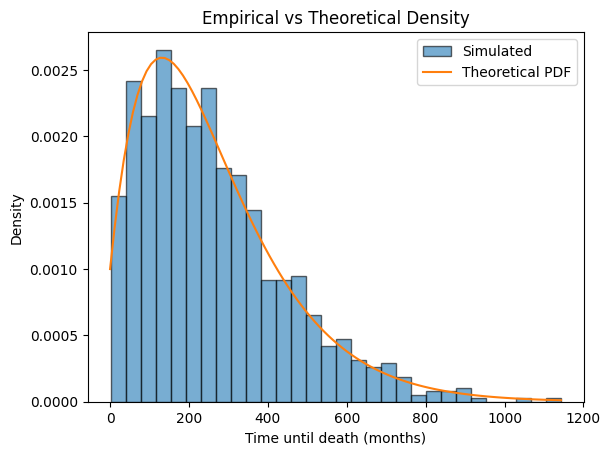

In [22]:
continuous_sorted = np.sort(continuous_matrix)

empirical_cdf = np.arange(1, len(continuous_sorted) + 1) / len(continuous_sorted)
x_values = np.linspace(0, continuous_matrix.max(), 100)

theoretical_cdf_values = np.array([
    theoretical_cdf(t) for t in x_values
])

exit_rates = -Qs @ np.ones(4)

pdf_values = np.array([
    p0 @ scipy.linalg.expm(Qs * t) @ exit_rates
    for t in x_values
])

plt.hist(continuous_matrix, bins=30, density=True, alpha=0.6,
         edgecolor='black', label='Simulated')

plt.plot(x_values, pdf_values, label='Theoretical PDF')

plt.title('Empirical vs Theoretical Density')
plt.xlabel('Time until death (months)')
plt.ylabel('Density')
plt.legend()
plt.show()

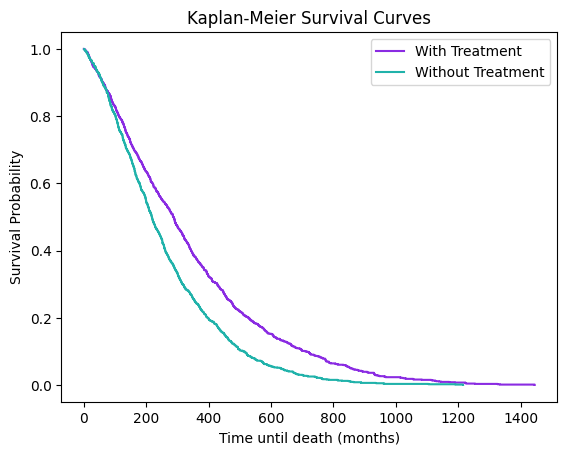

In [2]:
### Task 9
q11 = -(0.0025+0.00125+0.001)
q22 = -(0.002+0.005)
q33 = -(0.003+0.005)

Q_new = np.array([
    [q11, 0.0025, 0.00125, 0, 0.001],[0,q22, 0,0.002,0.005],[0,0,q33,0.003,0.005],[0,0,0,-0.009,0.009],[0,0,0,0,0]])

simulated_data_new = continuous_cancer_simulation(1000, Q_new)
simulated_data_old = continuous_cancer_simulation(1000, Q)
    
times_new, survival_with_treatment = kaplan_meier_estimate(simulated_data_new)
times_old, survival_without_treatment = kaplan_meier_estimate(simulated_data_old)

plt.step(times_new, survival_with_treatment, where='post', label='With Treatment', color='blueviolet')
plt.step(times_old, survival_without_treatment, where='post', label='Without Treatment', color='lightseagreen')
plt.title('Kaplan-Meier Survival Curves')
plt.xlabel('Time until death (months)')
plt.ylabel('Survival Probability')
plt.legend()
plt.savefig('kaplan_meier_comparison.png')
plt.show()

#### Part 3

In [3]:
# Task 12
n = 1000

ts_women = continuous_cancer_simulation(n, Q)
ts_state_women = []


for woman in ts_women:

    jump_times = [t for t, s in woman[2]]
    states = [s for t, s in woman[2]]

    y = time_series_observation(
        jump_times,
        states,
        observation_gap=48
    )

    ts_state_women.append(y)


print(f"Example of observed time series for one patient: {ts_state_women[0]}")

Example of observed time series for one patient: [0, 0, 1, 1, 3, 3, 3, 3, 3, 3, 4]


In [8]:
# Task 13
np.random.seed(42)
estimated_Q = MCEM(ts_state_women, Q)
print("Estimated Q matrix:")
print(estimated_Q)

Estimated Q matrix:
[[-0.00826662  0.00477811  0.00243865  0.          0.00104986]
 [ 0.         -0.01551785  0.00539634  0.00467146  0.00545004]
 [ 0.          0.         -0.0080558   0.00267985  0.00537595]
 [ 0.          0.          0.         -0.00873717  0.00873717]
 [ 0.          0.          0.          0.         -0.        ]]
